In [ ]:
# --- Data ---

import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- TFT & time series forecasting (PyTorch) ---
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
# from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters  # optional

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Preprocessing & metrics ---
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Utilities ---
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [55]:
# ── Load raw files ─────────────────────────────────────────────────────────────
top50 = pd.read_csv("top50_adjclose_2010_2025.csv", parse_dates=["Date"])
unp   = pd.read_csv("unp_us_d.csv",                 parse_dates=["Date"])
spx   = pd.read_csv("^spx_d.csv",                    parse_dates=["Date"])

top50 = top50[["Date", "AAPL", "JPM", "XOM", "JNJ"]].copy()
unp   = unp[["Date", "Close"]].rename(columns={"Close": "UNP"})
spx   = spx[["Date", "Close"]].rename(columns={"Close": "SPX"})

# ── Merge everything on Date (inner join = common trading days only) ────────────
df = top50.merge(unp, on="Date", how="inner") \
          .merge(spx, on="Date", how="inner")

# ── Filter to 2015-01-01 → last date where ALL sources have data ───────────────
df = df[df["Date"] >= "2015-01-01"].reset_index(drop=True)

df = df.set_index("Date")

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing values:\n{df.isna().sum()}")
print(df.head(3))

Date range : 2015-01-02 → 2025-12-30
Trading days: 2765
Columns     : ['AAPL', 'JPM', 'XOM', 'JNJ', 'UNP', 'SPX']
Missing values:
AAPL    0
JPM     0
XOM     0
JNJ     0
UNP     0
SPX     0
dtype: int64
                 AAPL        JPM        XOM        JNJ      UNP      SPX
Date                                                                    
2015-01-02  24.237549  46.511147  57.916904  76.955574  99.4006  2058.20
2015-01-05  23.554741  45.067200  56.332180  76.418091  96.0670  2020.58
2015-01-06  23.556957  43.898647  56.032707  76.042587  94.0529  2002.61


In [56]:
TICKERS = ["AAPL", "JPM", "XOM", "JNJ", "UNP"]

# ── Log returns ────────────────────────────────────────────────────────────────
for t in TICKERS:
    df[f"{t}_ret"] = np.log(df[t] / df[t].shift(1))

df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

# ── Rolling MAs of log returns (per stock only, as per proposal) ───────────────
for t in TICKERS:
    df[f"{t}_MA5"]  = df[f"{t}_ret"].rolling(5).mean()
    df[f"{t}_MA21"] = df[f"{t}_ret"].rolling(21).mean()
    df[f"{t}_MA63"] = df[f"{t}_ret"].rolling(63).mean()

# ── Rolling volatility of log returns (per stock only) ────────────────────────
for t in TICKERS:
    df[f"{t}_VOL5"]  = df[f"{t}_ret"].rolling(5).std()
    df[f"{t}_VOL21"] = df[f"{t}_ret"].rolling(21).std()
    df[f"{t}_VOL63"] = df[f"{t}_ret"].rolling(63).std()

# ── Shared SPX rolling volatility ─────────────────────────────────────────────
df["SPX_VOL21"] = df["SPX_ret"].rolling(21).std()

# ── Drop raw prices (no longer needed) and first 63 rows (NaN warmup) ─────────
price_cols = TICKERS + ["SPX"]
df = df.drop(columns=price_cols)
df = df.iloc[63:].copy()

# ── Reorder columns: SPX shared features first, then per-stock blocks ──────────
spx_cols    = ["SPX_ret", "SPX_VOL21"]
stock_cols  = [f"{t}{s}" for t in TICKERS 
               for s in ["_ret", "_MA5", "_MA21", "_MA63", "_VOL5", "_VOL21", "_VOL63"]]

df = df[spx_cols + stock_cols]

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Date range  : {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing values:\n{df.isna().sum()}")
print(df.head(3))

Date range  : 2015-04-06 → 2025-12-30
Trading days: 2702
Columns     : ['SPX_ret', 'SPX_VOL21', 'AAPL_ret', 'AAPL_MA5', 'AAPL_MA21', 'AAPL_MA63', 'AAPL_VOL5', 'AAPL_VOL21', 'AAPL_VOL63', 'JPM_ret', 'JPM_MA5', 'JPM_MA21', 'JPM_MA63', 'JPM_VOL5', 'JPM_VOL21', 'JPM_VOL63', 'XOM_ret', 'XOM_MA5', 'XOM_MA21', 'XOM_MA63', 'XOM_VOL5', 'XOM_VOL21', 'XOM_VOL63', 'JNJ_ret', 'JNJ_MA5', 'JNJ_MA21', 'JNJ_MA63', 'JNJ_VOL5', 'JNJ_VOL21', 'JNJ_VOL63', 'UNP_ret', 'UNP_MA5', 'UNP_MA21', 'UNP_MA63', 'UNP_VOL5', 'UNP_VOL21', 'UNP_VOL63']
Missing values:
SPX_ret       0
SPX_VOL21     0
AAPL_ret      0
AAPL_MA5      0
AAPL_MA21     0
AAPL_MA63     0
AAPL_VOL5     0
AAPL_VOL21    0
AAPL_VOL63    0
JPM_ret       0
JPM_MA5       0
JPM_MA21      0
JPM_MA63      0
JPM_VOL5      0
JPM_VOL21     0
JPM_VOL63     0
XOM_ret       0
XOM_MA5       0
XOM_MA21      0
XOM_MA63      0
XOM_VOL5      0
XOM_VOL21     0
XOM_VOL63     0
JNJ_ret       0
JNJ_MA5       0
JNJ_MA21      0
JNJ_MA63      0
JNJ_VOL5      0
JNJ_VOL21    

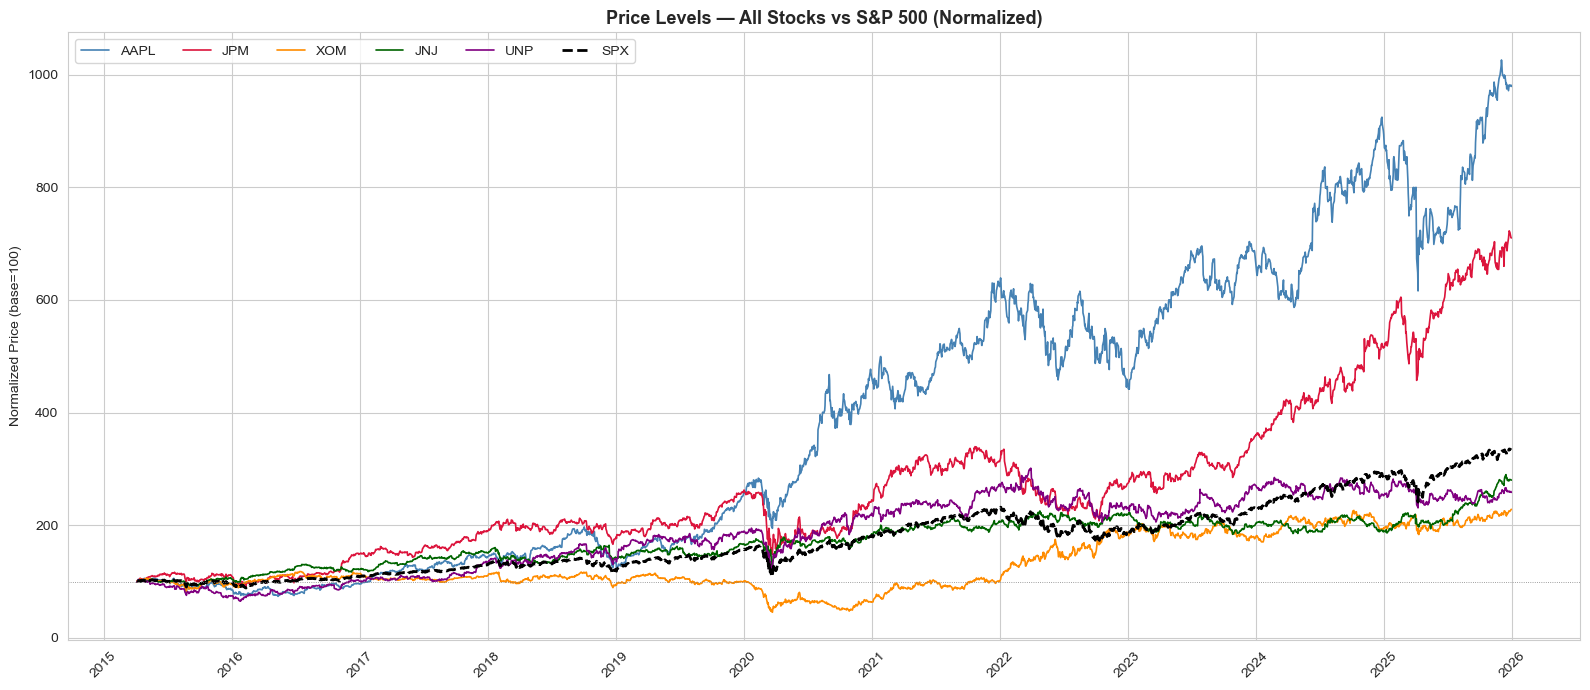

In [57]:
ALL_TICKERS = TICKERS + ["SPX"]

prices_norm = df[[f"{t}_ret" for t in ALL_TICKERS]].cumsum().apply(np.exp) * 100
prices_norm.columns = ALL_TICKERS

fig, ax = plt.subplots(figsize=(16, 7))

colors = {"AAPL":"steelblue", "JPM":"crimson", "XOM":"darkorange",
          "JNJ":"darkgreen",  "UNP":"purple",  "SPX":"black"}

for col in ALL_TICKERS:
    lw = 2.0 if col == "SPX" else 1.2
    ls = "--" if col == "SPX" else "-"
    ax.plot(prices_norm.index, prices_norm[col], label=col,
            color=colors[col], lw=lw, linestyle=ls)

ax.axhline(100, color="grey", lw=0.6, linestyle=":")
ax.set_ylabel("Normalized Price (base=100)", fontsize=10)
ax.set_title("Price Levels — All Stocks vs S&P 500 (Normalized)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, ncol=6, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

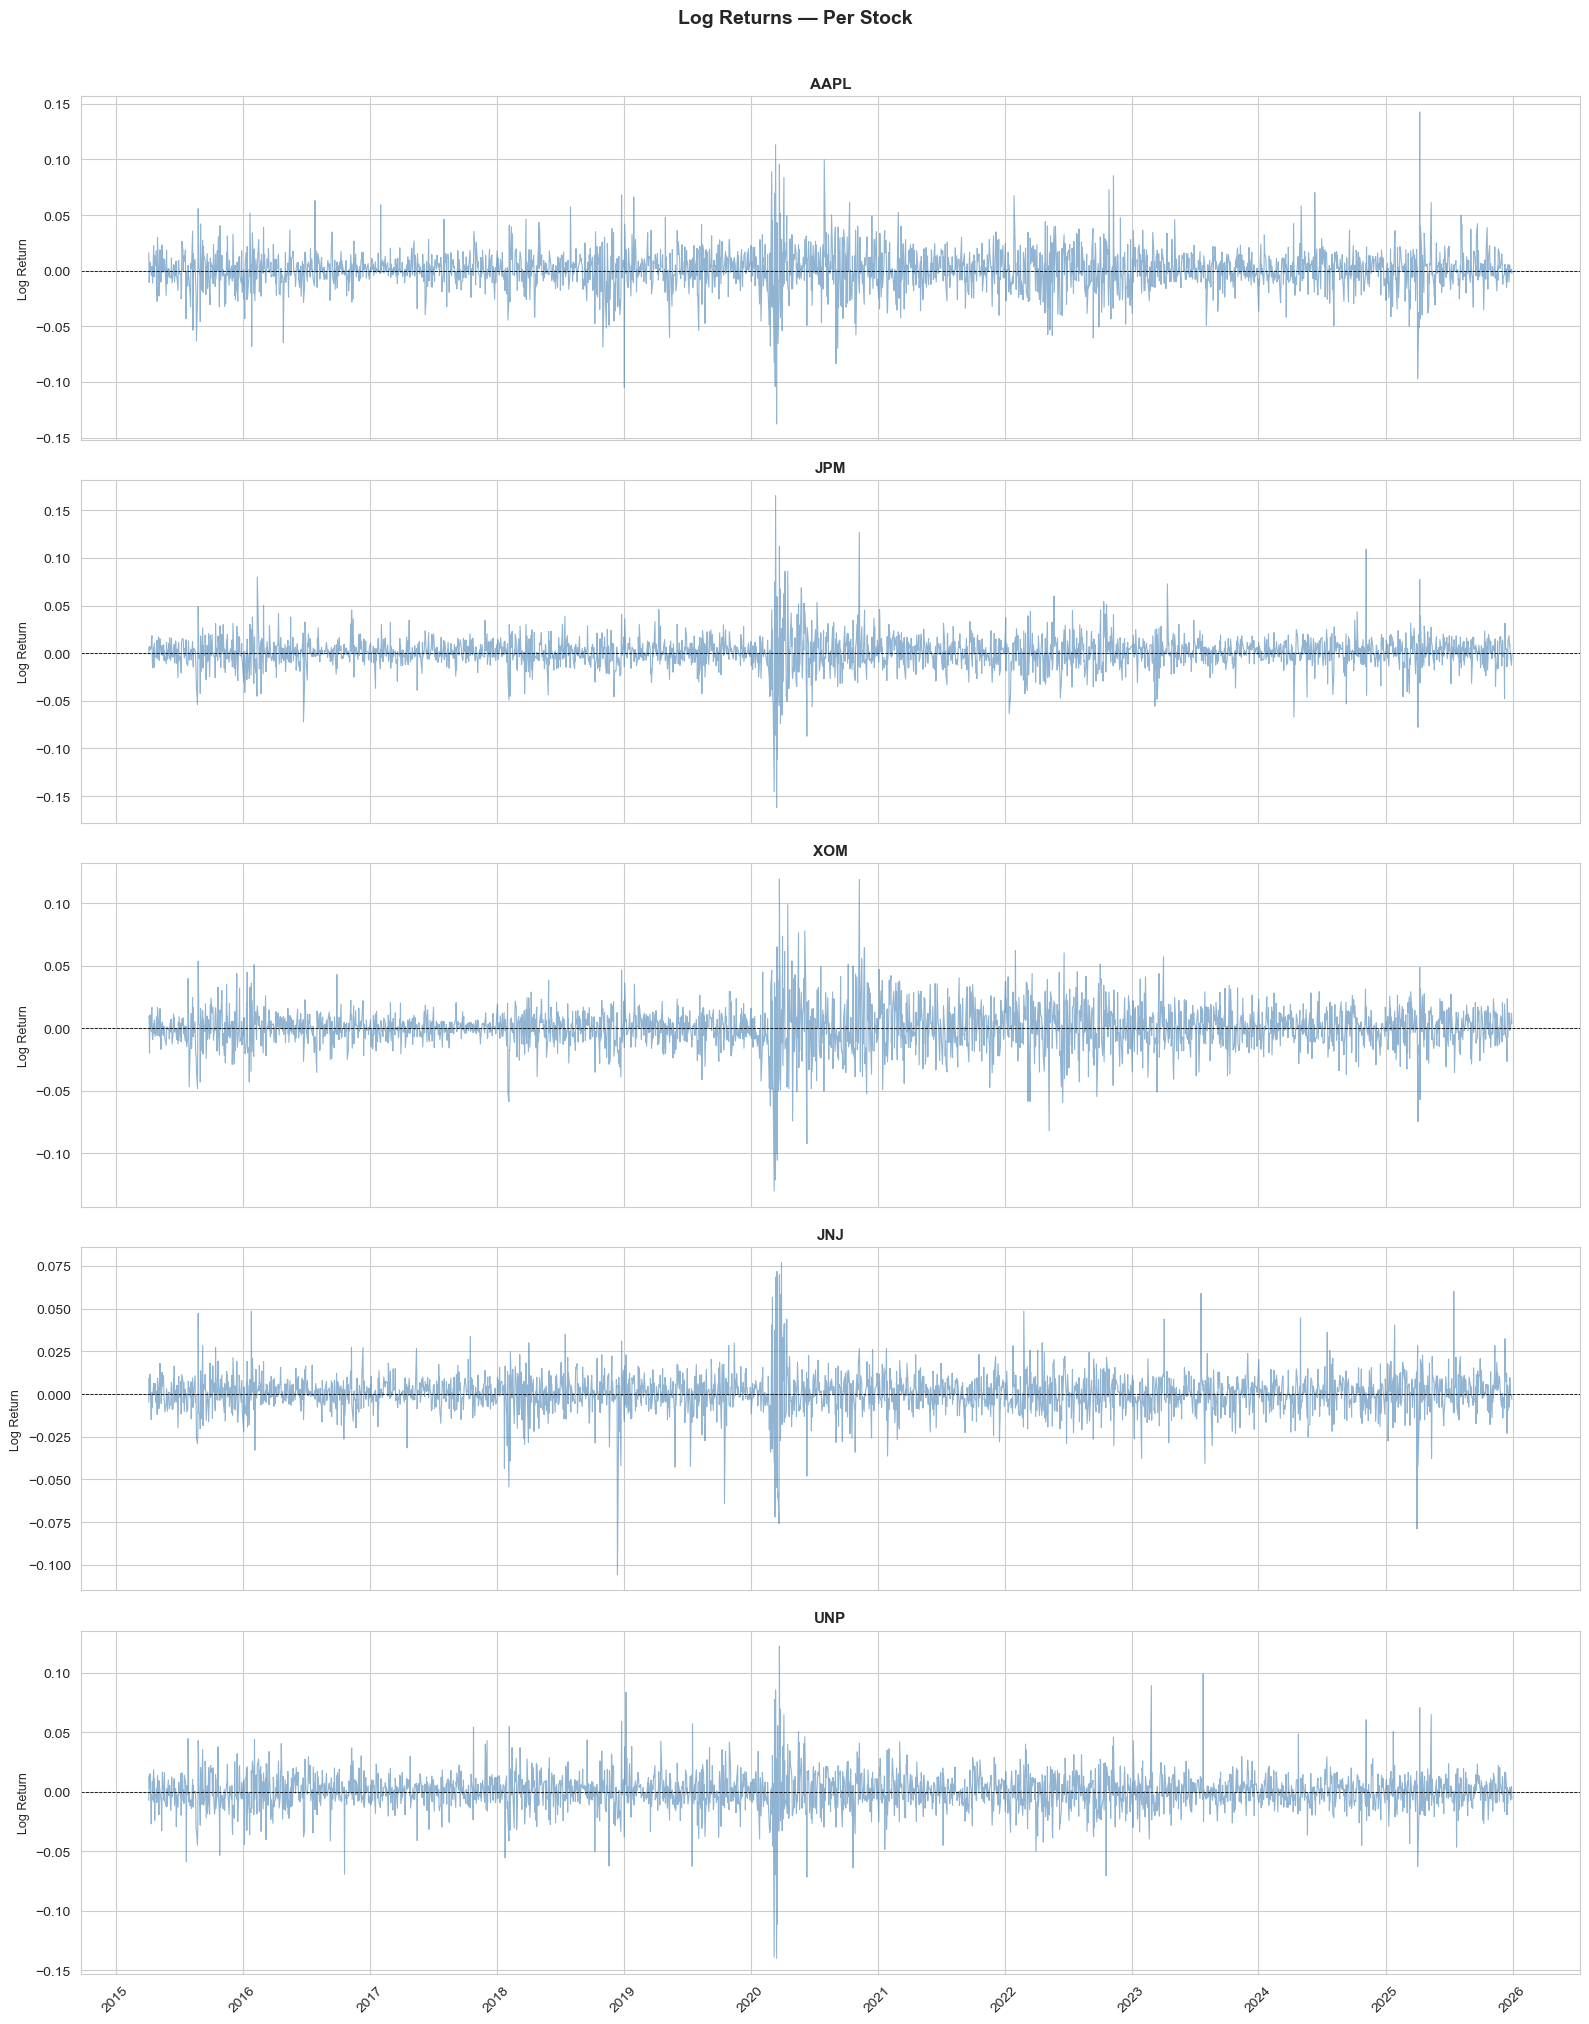

In [58]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, t in zip(axes, TICKERS):
    ax.plot(df.index, df[f"{t}_ret"], color="steelblue", alpha=0.6, lw=0.8, label="Log Return")
    ax.axhline(0, color="black", lw=0.6, linestyle="--")
    ax.set_ylabel("Log Return", fontsize=9)
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Log Returns — Per Stock", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [59]:
# ── Basic info ─────────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDescriptive stats:\n", df.describe())

Shape: (2702, 37)

Descriptive stats:
            SPX_ret    SPX_VOL21     AAPL_ret     AAPL_MA5    AAPL_MA21  \
count  2702.000000  2702.000000  2702.000000  2702.000000  2702.000000   
mean      0.000446     0.009458     0.000844     0.000846     0.000849   
std       0.011364     0.006419     0.018181     0.007708     0.003767   
min      -0.127652     0.002185    -0.137708    -0.051618    -0.015928   
25%      -0.003747     0.005775    -0.007270    -0.003376    -0.001389   
50%       0.000710     0.007815     0.000898     0.001260     0.001128   
75%       0.005735     0.011659     0.009841     0.005363     0.003496   
max       0.090895     0.061454     0.142617     0.033803     0.014691   

         AAPL_MA63    AAPL_VOL5   AAPL_VOL21   AAPL_VOL63      JPM_ret  ...  \
count  2702.000000  2702.000000  2702.000000  2702.000000  2702.000000  ...   
mean      0.000852     0.015281     0.016443     0.017052     0.000725  ...   
std       0.002142     0.010267     0.007893     0.006478

In [60]:
SECTOR_MAP = {
    "AAPL": "Technology",
    "JPM":  "Financials",
    "XOM":  "Energy",
    "JNJ":  "Healthcare",
    "UNP":  "Industrials",
}

In [61]:
# ── Convert to long format ─────────────────────────────────────────────────────
records = []

for t in TICKERS:
    tmp = pd.DataFrame({
        "date"       : df.index,
        "stock_id"   : t,
        "sector"     : SECTOR_MAP[t],
        "log_return" : df[f"{t}_ret"].values,
        "MA_5"       : df[f"{t}_MA5"].values,
        "MA_21"      : df[f"{t}_MA21"].values,
        "MA_63"      : df[f"{t}_MA63"].values,
        "VOL_5"      : df[f"{t}_VOL5"].values,
        "VOL_21"     : df[f"{t}_VOL21"].values,
        "VOL_63"     : df[f"{t}_VOL63"].values,
        "SP500_ret"  : df["SPX_ret"].values,
        "SP500_VOL21": df["SPX_VOL21"].values,
        "day_of_week": df.index.dayofweek,
        "month"      : df.index.month,
    })
    records.append(tmp)

panel = pd.concat(records, ignore_index=True)
panel = panel.sort_values(["date", "stock_id"]).reset_index(drop=True)

# ── Add global time index ──────────────────────────────────────────────────────
date_to_idx = {d: i for i, d in enumerate(sorted(panel["date"].unique()))}
panel["time_idx"] = panel["date"].map(date_to_idx)

# ── Add train/val/test split ───────────────────────────────────────────────────
T = panel["time_idx"].max()
panel["split"] = pd.cut(
    panel["time_idx"],
    bins=[-1, int(0.70 * T), int(0.85 * T), T],
    labels=["train", "val", "test"]
)

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Shape       : {panel.shape}")
print(f"Date range  : {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"Stocks      : {panel['stock_id'].unique().tolist()}")
print(f"Split counts:\n{panel['split'].value_counts().sort_index()}")
print(panel.head(10))

Shape       : (13510, 16)
Date range  : 2015-04-06 → 2025-12-30
Stocks      : ['AAPL', 'JNJ', 'JPM', 'UNP', 'XOM']
Split counts:
split
train    9455
val      2025
test     2030
Name: count, dtype: int64
        date stock_id       sector  log_return      MA_5     MA_21     MA_63  \
0 2015-04-06     AAPL   Technology    0.016069  0.006545  0.000353  0.002484   
1 2015-04-06      JNJ   Healthcare   -0.004829 -0.002366 -0.001587 -0.000725   
2 2015-04-06      JPM   Financials   -0.000826  0.004391 -0.000874 -0.000416   
3 2015-04-06      UNP  Industrials   -0.007183 -0.003857 -0.005072 -0.001655   
4 2015-04-06      XOM       Energy    0.009798  0.003675 -0.000892 -0.001255   
5 2015-04-07     AAPL   Technology   -0.010578 -0.000571 -0.000222  0.002770   
6 2015-04-07      JNJ   Healthcare    0.009435 -0.002876 -0.000005 -0.000464   
7 2015-04-07      JPM   Financials    0.006264  0.000964  0.000284  0.000184   
8 2015-04-07      UNP  Industrials    0.013556 -0.004162 -0.003674 -0.000898 

In [62]:
# ── 1. Unit test entity isolation ─────────────────────────────────────────────
for t in TICKERS:
    expected = (panel[panel.stock_id == t]["log_return"]
                .rolling(5)
                .mean()
                .reset_index(drop=True))
    actual = panel[panel.stock_id == t]["MA_5"].reset_index(drop=True)
    
    # compare ignoring NaNs at the start
    mask = expected.notna() & actual.notna()
    assert (expected[mask].round(10) == actual[mask].round(10)).all(), \
        f"MA_5 mismatch for {t}"
    print(f"✓ {t} MA_5 entity isolation passed")

print("\nAll unit tests passed.")

✓ AAPL MA_5 entity isolation passed
✓ JPM MA_5 entity isolation passed
✓ XOM MA_5 entity isolation passed
✓ JNJ MA_5 entity isolation passed
✓ UNP MA_5 entity isolation passed

All unit tests passed.


In [63]:
# ── 2. Split boundaries ────────────────────────────────────────────────────────
for split in ["train", "val", "test"]:
    subset = panel[panel.split == split]["date"]
    print(f"{split:5s} : {subset.min().date()} → {subset.max().date()}  ({subset.nunique()} trading days)")

train : 2015-04-06 → 2022-10-05  (1891 trading days)
val   : 2022-10-06 → 2024-05-16  (405 trading days)
test  : 2024-05-17 → 2025-12-30  (406 trading days)


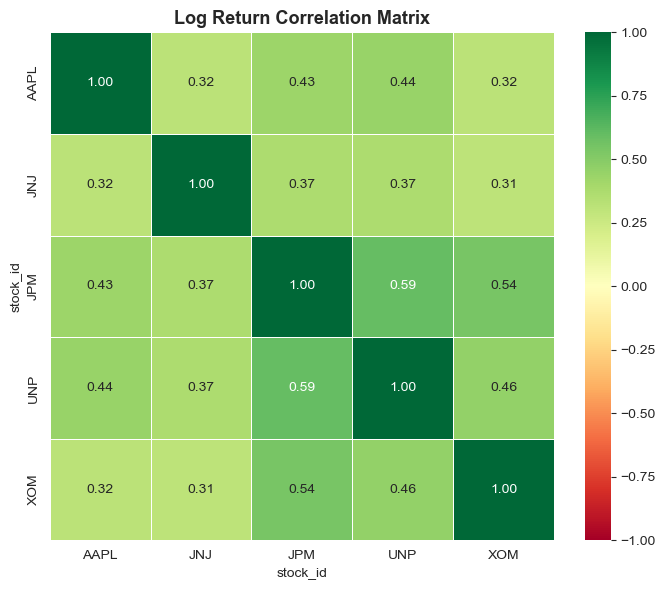

In [64]:
# ── 3. Correlation matrix of log returns ──────────────────────────────────────

ret_wide = panel.pivot(index="date", columns="stock_id", values="log_return")
corr = ret_wide.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Log Return Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

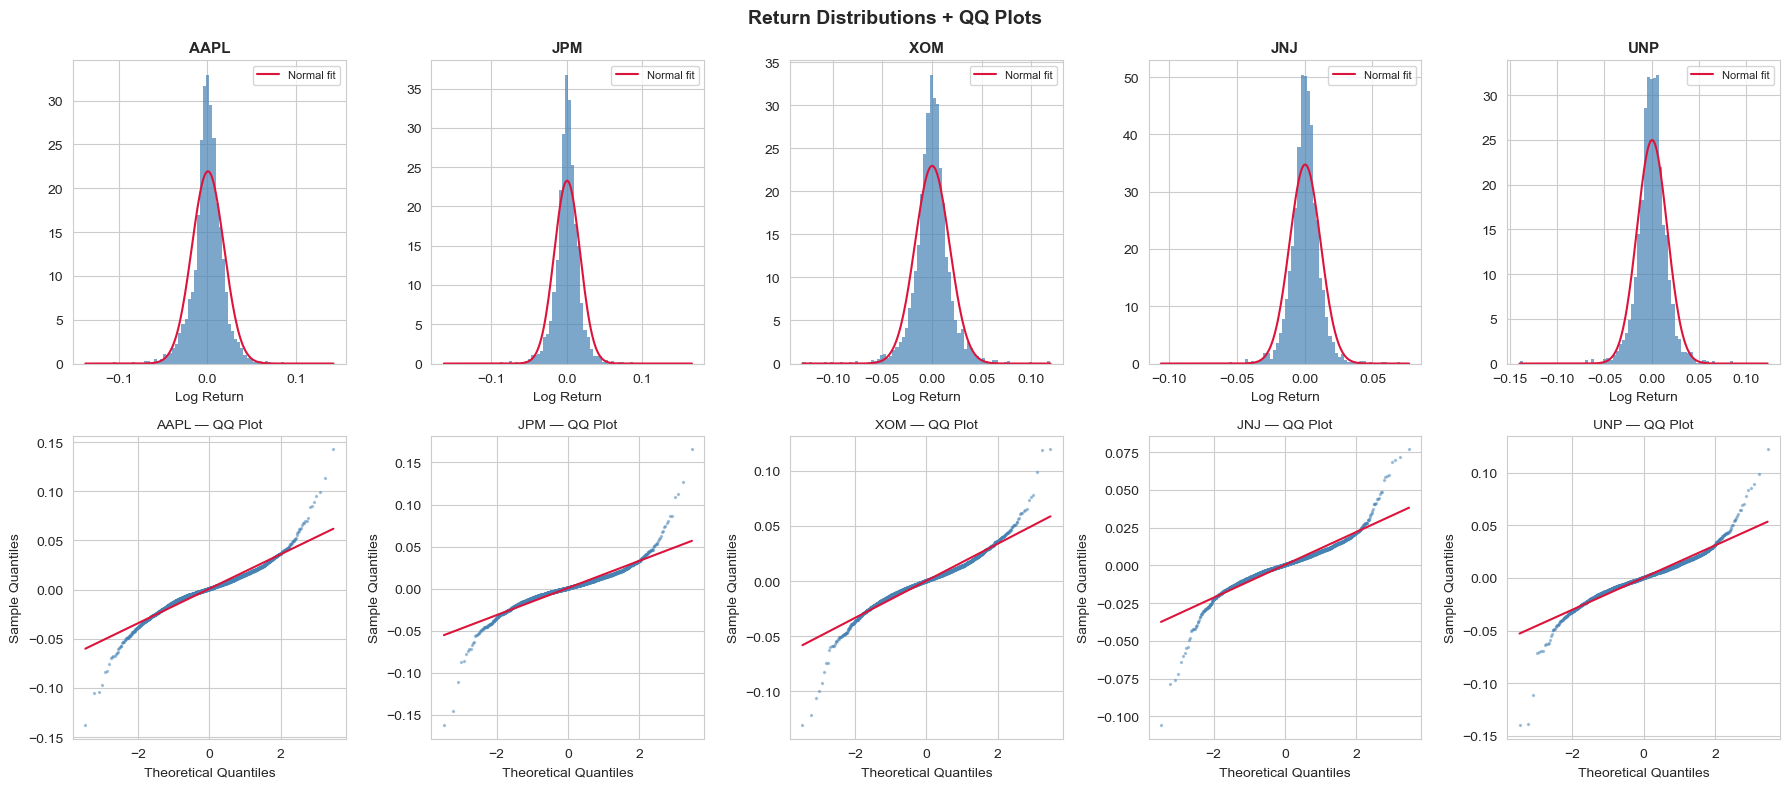

In [65]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, t in enumerate(TICKERS):
    rets = panel[panel.stock_id == t]["log_return"].dropna()

    # histogram
    ax = axes[0, i]
    ax.hist(rets, bins=80, color="steelblue", edgecolor="none", alpha=0.7, density=True)
    x = np.linspace(rets.min(), rets.max(), 200)
    ax.plot(x, stats.norm.pdf(x, rets.mean(), rets.std()),
            color="crimson", lw=1.5, label="Normal fit")
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.set_xlabel("Log Return")
    ax.legend(fontsize=8)

    # QQ plot — manual
    ax = axes[1, i]
    osm, osr = stats.probplot(rets, dist="norm")[:2]
    theoretical_q, ordered_vals = osm
    ax.scatter(theoretical_q, ordered_vals, s=2, alpha=0.4, color="steelblue")
    ax.plot(theoretical_q, theoretical_q * osr[0] + osr[1], color="crimson", lw=1.5)
    ax.set_title(f"{t} — QQ Plot", fontsize=10)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

fig.suptitle("Return Distributions + QQ Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

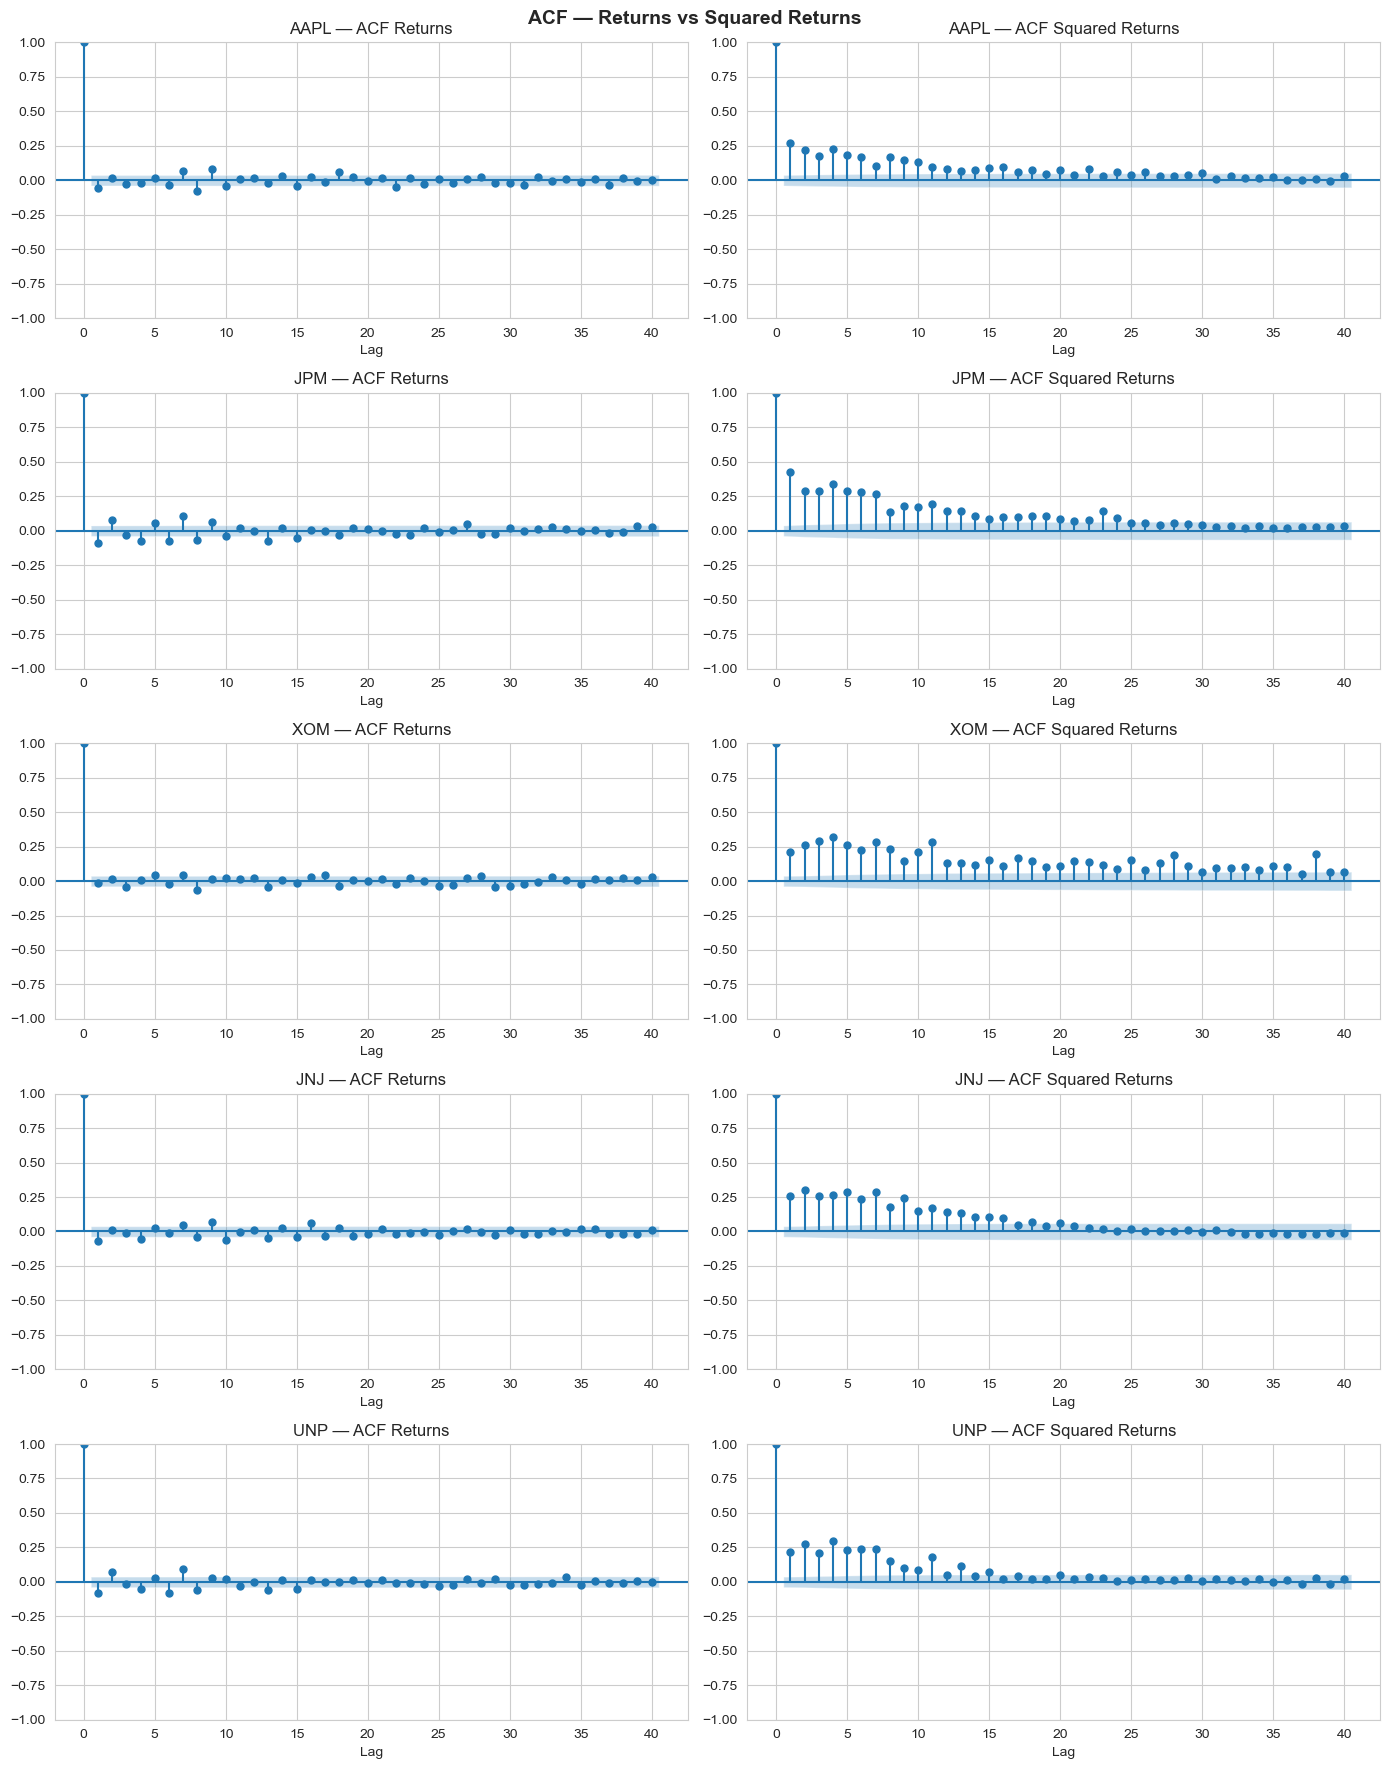

In [66]:
# ── 5. ACF of returns and squared returns ─────────────────────────────────────

fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for i, t in enumerate(TICKERS):
    rets = panel[panel.stock_id == t]["log_return"].dropna()

    plot_acf(rets,    ax=axes[i, 0], lags=40, alpha=0.05, title=f"{t} — ACF Returns")
    plot_acf(rets**2, ax=axes[i, 1], lags=40, alpha=0.05, title=f"{t} — ACF Squared Returns")

    axes[i, 0].set_xlabel("Lag")
    axes[i, 1].set_xlabel("Lag")

fig.suptitle("ACF — Returns vs Squared Returns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

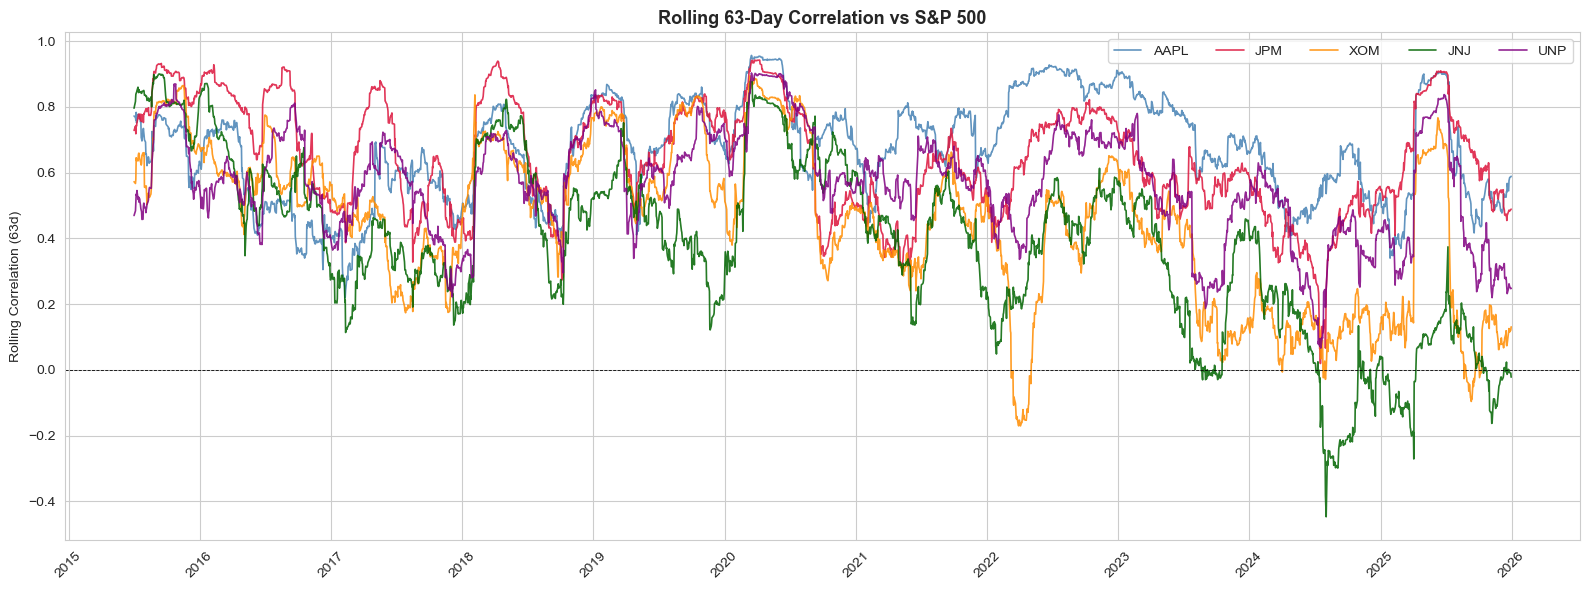

In [67]:
# ── 6. Rolling correlation of each stock vs SPX ────────────────────────────────
window = 63  # 1 quarter

fig, ax = plt.subplots(figsize=(16, 6))

colors_tickers = {"AAPL":"steelblue", "JPM":"crimson", "XOM":"darkorange",
                  "JNJ":"darkgreen",  "UNP":"purple"}

for t in TICKERS:
    stock_rets = panel[panel.stock_id == t].set_index("date")["log_return"]
    spx_rets   = panel[panel.stock_id == t].set_index("date")["SP500_ret"]
    rolling_corr = stock_rets.rolling(window).corr(spx_rets)
    ax.plot(rolling_corr.index, rolling_corr, label=t,
            color=colors_tickers[t], lw=1.2, alpha=0.85)

ax.axhline(0, color="black", lw=0.6, linestyle="--")
ax.set_ylabel("Rolling Correlation (63d)", fontsize=10)
ax.set_title("Rolling 63-Day Correlation vs S&P 500", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, ncol=5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

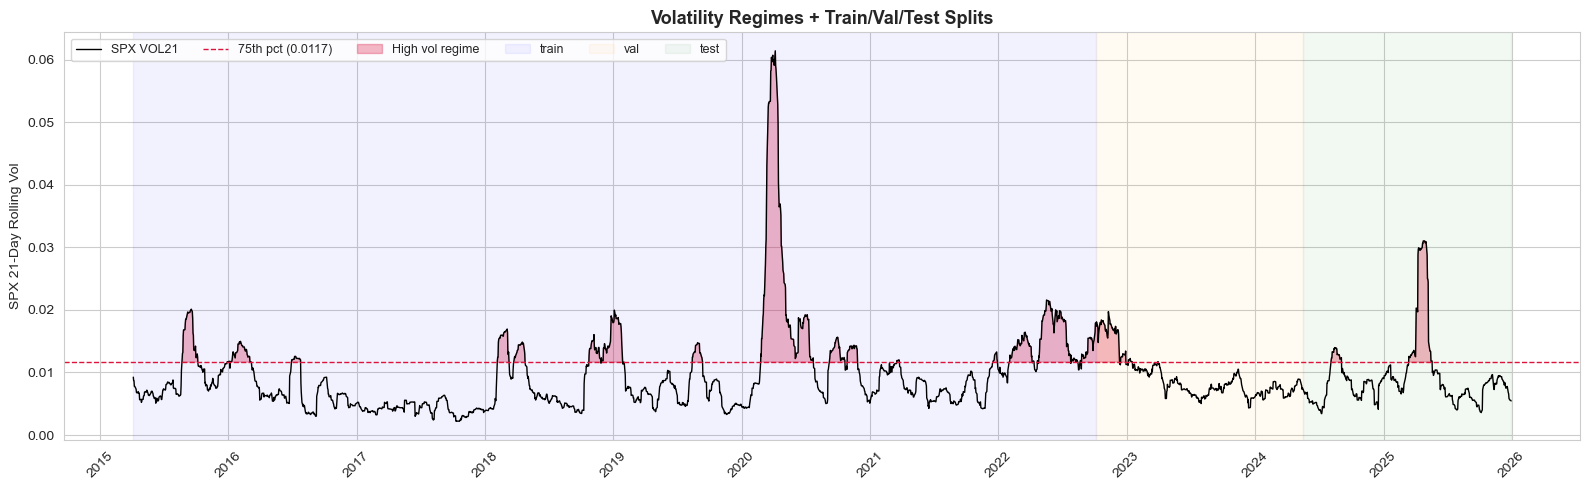

In [68]:
# ── 7. Volatility regime plot ──────────────────────────────────────────────────
spx_vol = panel[panel.stock_id == "AAPL"].set_index("date")["SP500_VOL21"]

# define high vol threshold as 75th percentile
threshold = spx_vol.quantile(0.75)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(spx_vol.index, spx_vol, color="black", lw=1.0, label="SPX VOL21")
ax.axhline(threshold, color="crimson", lw=1.0, linestyle="--", label=f"75th pct ({threshold:.4f})")
ax.fill_between(spx_vol.index, spx_vol, threshold,
                where=(spx_vol >= threshold),
                color="crimson", alpha=0.3, label="High vol regime")

# shade train/val/test regions
split_colors = {"train":"blue", "val":"orange", "test":"green"}
for split, color in split_colors.items():
    dates = panel[panel.split == split]["date"]
    ax.axvspan(dates.min(), dates.max(), alpha=0.05, color=color, label=split)

ax.set_ylabel("SPX 21-Day Rolling Vol", fontsize=10)
ax.set_title("Volatility Regimes + Train/Val/Test Splits", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=7, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# ── 8. Save panel to CSV ───────────────────────────────────────────────────────
panel.to_csv("tft_panel.csv", index=False)
print(f"Saved tft_panel.csv — {panel.shape[0]} rows x {panel.shape[1]} cols")

Saved tft_panel.csv — 13510 rows x 16 cols


In [70]:
# ── Load panel ─────────────────────────────────────────────────────────────────
panel = pd.read_csv("tft_panel.csv", parse_dates=["date"])

# sector and split must be strings/categoricals, not inferred numeric
panel["stock_id"] = panel["stock_id"].astype(str)
panel["sector"]   = panel["sector"].astype(str)
panel["split"]    = panel["split"].astype(str)

print(f"Shape       : {panel.shape}")
print(f"Date range  : {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"Columns     : {panel.columns.tolist()}")
print(f"Splits      : {panel['split'].value_counts().to_dict()}")
print(panel.head(3))

Shape       : (13510, 16)
Date range  : 2015-04-06 → 2025-12-30
Columns     : ['date', 'stock_id', 'sector', 'log_return', 'MA_5', 'MA_21', 'MA_63', 'VOL_5', 'VOL_21', 'VOL_63', 'SP500_ret', 'SP500_VOL21', 'day_of_week', 'month', 'time_idx', 'split']
Splits      : {'train': 9455, 'test': 2030, 'val': 2025}
        date stock_id      sector  log_return      MA_5     MA_21     MA_63  \
0 2015-04-06     AAPL  Technology    0.016069  0.006545  0.000353  0.002484   
1 2015-04-06      JNJ  Healthcare   -0.004829 -0.002366 -0.001587 -0.000725   
2 2015-04-06      JPM  Financials   -0.000826  0.004391 -0.000874 -0.000416   

      VOL_5    VOL_21    VOL_63  SP500_ret  SP500_VOL21  day_of_week  month  \
0  0.015684  0.014203  0.017147   0.006587     0.009252            0      4   
1  0.010752  0.011728  0.011453   0.006587     0.009252            0      4   
2  0.012199  0.012135  0.014984   0.006587     0.009252            0      4   

   time_idx  split  
0         0  train  
1         0  tra

In [71]:
# ── Cast known categoricals to string ──────────────────────────────────────────
panel["day_of_week"] = panel["day_of_week"].astype(str)
panel["month"]       = panel["month"].astype(str)

# ── Training dataset ───────────────────────────────────────────────────────────
train_df = panel[panel["split"] == "train"].copy()

training = TimeSeriesDataSet(
    data=train_df,
    group_ids=["stock_id"],
    target="log_return",
    time_idx="time_idx",
    min_encoder_length=63,
    max_encoder_length=126,
    min_prediction_length=1,
    max_prediction_length=1,
    static_categoricals=["sector"],
    time_varying_known_categoricals=["day_of_week", "month"],
    time_varying_unknown_reals=[
        "log_return",
        "MA_5", "MA_21", "MA_63",
        "VOL_5", "VOL_21", "VOL_63",
        "SP500_ret", "SP500_VOL21",
    ],
    target_normalizer=None,
)

print(training)

TimeSeriesDataSet[length=9455](
	time_idx='time_idx',
	target='log_return',
	group_ids=['stock_id'],
	weight=None,
	max_encoder_length=126,
	min_encoder_length=63,
	min_prediction_idx=0,
	min_prediction_length=1,
	max_prediction_length=1,
	static_categoricals=['sector'],
	static_reals=None,
	time_varying_known_categoricals=['day_of_week', 'month'],
	time_varying_known_reals=None,
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['log_return', 'MA_5', 'MA_21', 'MA_63', 'VOL_5', 'VOL_21', 'VOL_63', 'SP500_ret', 'SP500_VOL21'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=False,
	lags=None,
	add_relative_time_idx=False,
	add_target_scales=False,
	add_encoder_length=True,
	target_normalizer=TorchNormalizer(method='identity', center=True, transformation=None, method_kwargs=None),
	categorical_encoders={'__group_id__stock_id': NaNLabelEncoder(add_nan=False, warn=True), 'sector': NaNLabelEncoder(add_nan=False, warn=True), 'day_of_week': NaN

In [72]:
# ── Validation dataset ─────────────────────────────────────────────────────────
val_df = panel[panel["split"] == "val"].copy()

validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=False)

print(validation)

TimeSeriesDataSet[length=2025](
	time_idx='time_idx',
	target='log_return',
	group_ids=['stock_id'],
	weight=None,
	max_encoder_length=126,
	min_encoder_length=63,
	min_prediction_idx=0,
	min_prediction_length=1,
	max_prediction_length=1,
	static_categoricals=['sector'],
	static_reals=None,
	time_varying_known_categoricals=['day_of_week', 'month'],
	time_varying_known_reals=None,
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['log_return', 'MA_5', 'MA_21', 'MA_63', 'VOL_5', 'VOL_21', 'VOL_63', 'SP500_ret', 'SP500_VOL21'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=False,
	lags=None,
	add_relative_time_idx=False,
	add_target_scales=False,
	add_encoder_length=True,
	target_normalizer=TorchNormalizer(method='identity', center=True, transformation=None, method_kwargs=None),
	categorical_encoders={'__group_id__stock_id': NaNLabelEncoder(add_nan=False, warn=True), 'sector': NaNLabelEncoder(add_nan=False, warn=True), 'day_of_week': NaN

In [73]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
train_loader = training.to_dataloader(train=True,  batch_size=128, num_workers=0)
val_loader   = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 73
Val batches   : 16


In [74]:
# ── Model ──────────────────────────────────────────────────────────────────────
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=16,
    lstm_layers=1,
    loss=QuantileLoss(quantiles=[0.025, 0.5, 0.975]),
    log_interval=10,
    reduce_on_plateau_patience=5,
)

print(f"Parameters : {sum(p.numel() for p in tft.parameters()):,}")

Parameters : 74,431


In [ ]:
# ── Trainer ────────────────────────────────────────────────────────────────────


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
    verbose=True,
)

checkpoint = ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints/",
    filename="tft-best",
    save_top_k=1,
    mode="min",
)

trainer = L.Trainer(
    max_epochs=100,
    accelerator="cpu",
    callbacks=[early_stop, checkpoint],
    enable_progress_bar=True,
    logger=False,
)

print("Trainer ready.")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Trainer ready.


In [78]:
# ── Train ──────────────────────────────────────────────────────────────────────
trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

print(f"Best model : {checkpoint.best_model_path}")
print(f"Best val loss : {checkpoint.best_model_score:.6f}")


   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 112    | train
3  | prescalers                         | ModuleDict                      | 320    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 2.0 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 19.1 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 306    | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 4.3 K  | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 4.3 K  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.010


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.004. Signaling Trainer to stop.


Best model : G:\My Drive\Temporal-Fusion-Transformer\checkpoints\tft-best.ckpt
Best val loss : 0.004019


In [81]:
# ── Load best model ────────────────────────────────────────────────────────────
best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint.best_model_path)
best_model.eval()

print(f"Loaded : {checkpoint.best_model_path}")

Loaded : G:\My Drive\Temporal-Fusion-Transformer\checkpoints\tft-best.ckpt


In [83]:
# ── Test dataset & predictions ─────────────────────────────────────────────────
test_df = panel[panel["split"] == "test"].copy()

test_dataset = TimeSeriesDataSet.from_dataset(training, test_df, predict=False)
test_loader  = test_dataset.to_dataloader(train=False, batch_size=128, num_workers=0)

predictions = best_model.predict(test_loader, mode="quantiles", return_x=True)

print(f"Prediction shape : {predictions.output.shape}")

Prediction shape : torch.Size([2030, 1, 3])


In [84]:
# ── Align predictions with actuals ─────────────────────────────────────────────
preds = predictions.output.numpy()  # shape [2030, 1, 3]

# get actuals and index from the test dataset
actuals    = torch.cat([y[0] for x, y in test_loader]).numpy()
index      = test_dataset.get_parameters()

# rebuild from test_df directly — safer alignment
test_sorted = test_df.sort_values(["time_idx", "stock_id"]).reset_index(drop=True)

results = pd.DataFrame({
    "date"      : test_sorted["date"].values,
    "stock_id"  : test_sorted["stock_id"].values,
    "actual"    : test_sorted["log_return"].values,
    "q025"      : preds[:, 0, 0],
    "q050"      : preds[:, 0, 1],
    "q975"      : preds[:, 0, 2],
})

print(results.shape)
print(results.head(10))

(2030, 6)
        date stock_id    actual      q025      q050      q975
0 2024-05-17     AAPL  0.000158 -0.027825  0.003790  0.033711
1 2024-05-17      JNJ  0.002331 -0.030066  0.001038  0.030680
2 2024-05-17      JPM  0.011393 -0.025814  0.000560  0.024966
3 2024-05-17      UNP -0.003789 -0.025350  0.002303  0.031484
4 2024-05-17      XOM  0.014905 -0.025684  0.001000  0.018120
5 2024-05-20     AAPL  0.006143 -0.026293  0.003884  0.031878
6 2024-05-20      JNJ -0.013983 -0.023569  0.001291  0.025476
7 2024-05-20      JPM -0.046016 -0.022558  0.000624  0.022433
8 2024-05-20      UNP -0.005485 -0.023366  0.002311  0.029751
9 2024-05-20      XOM -0.008141 -0.027315  0.003691  0.030716


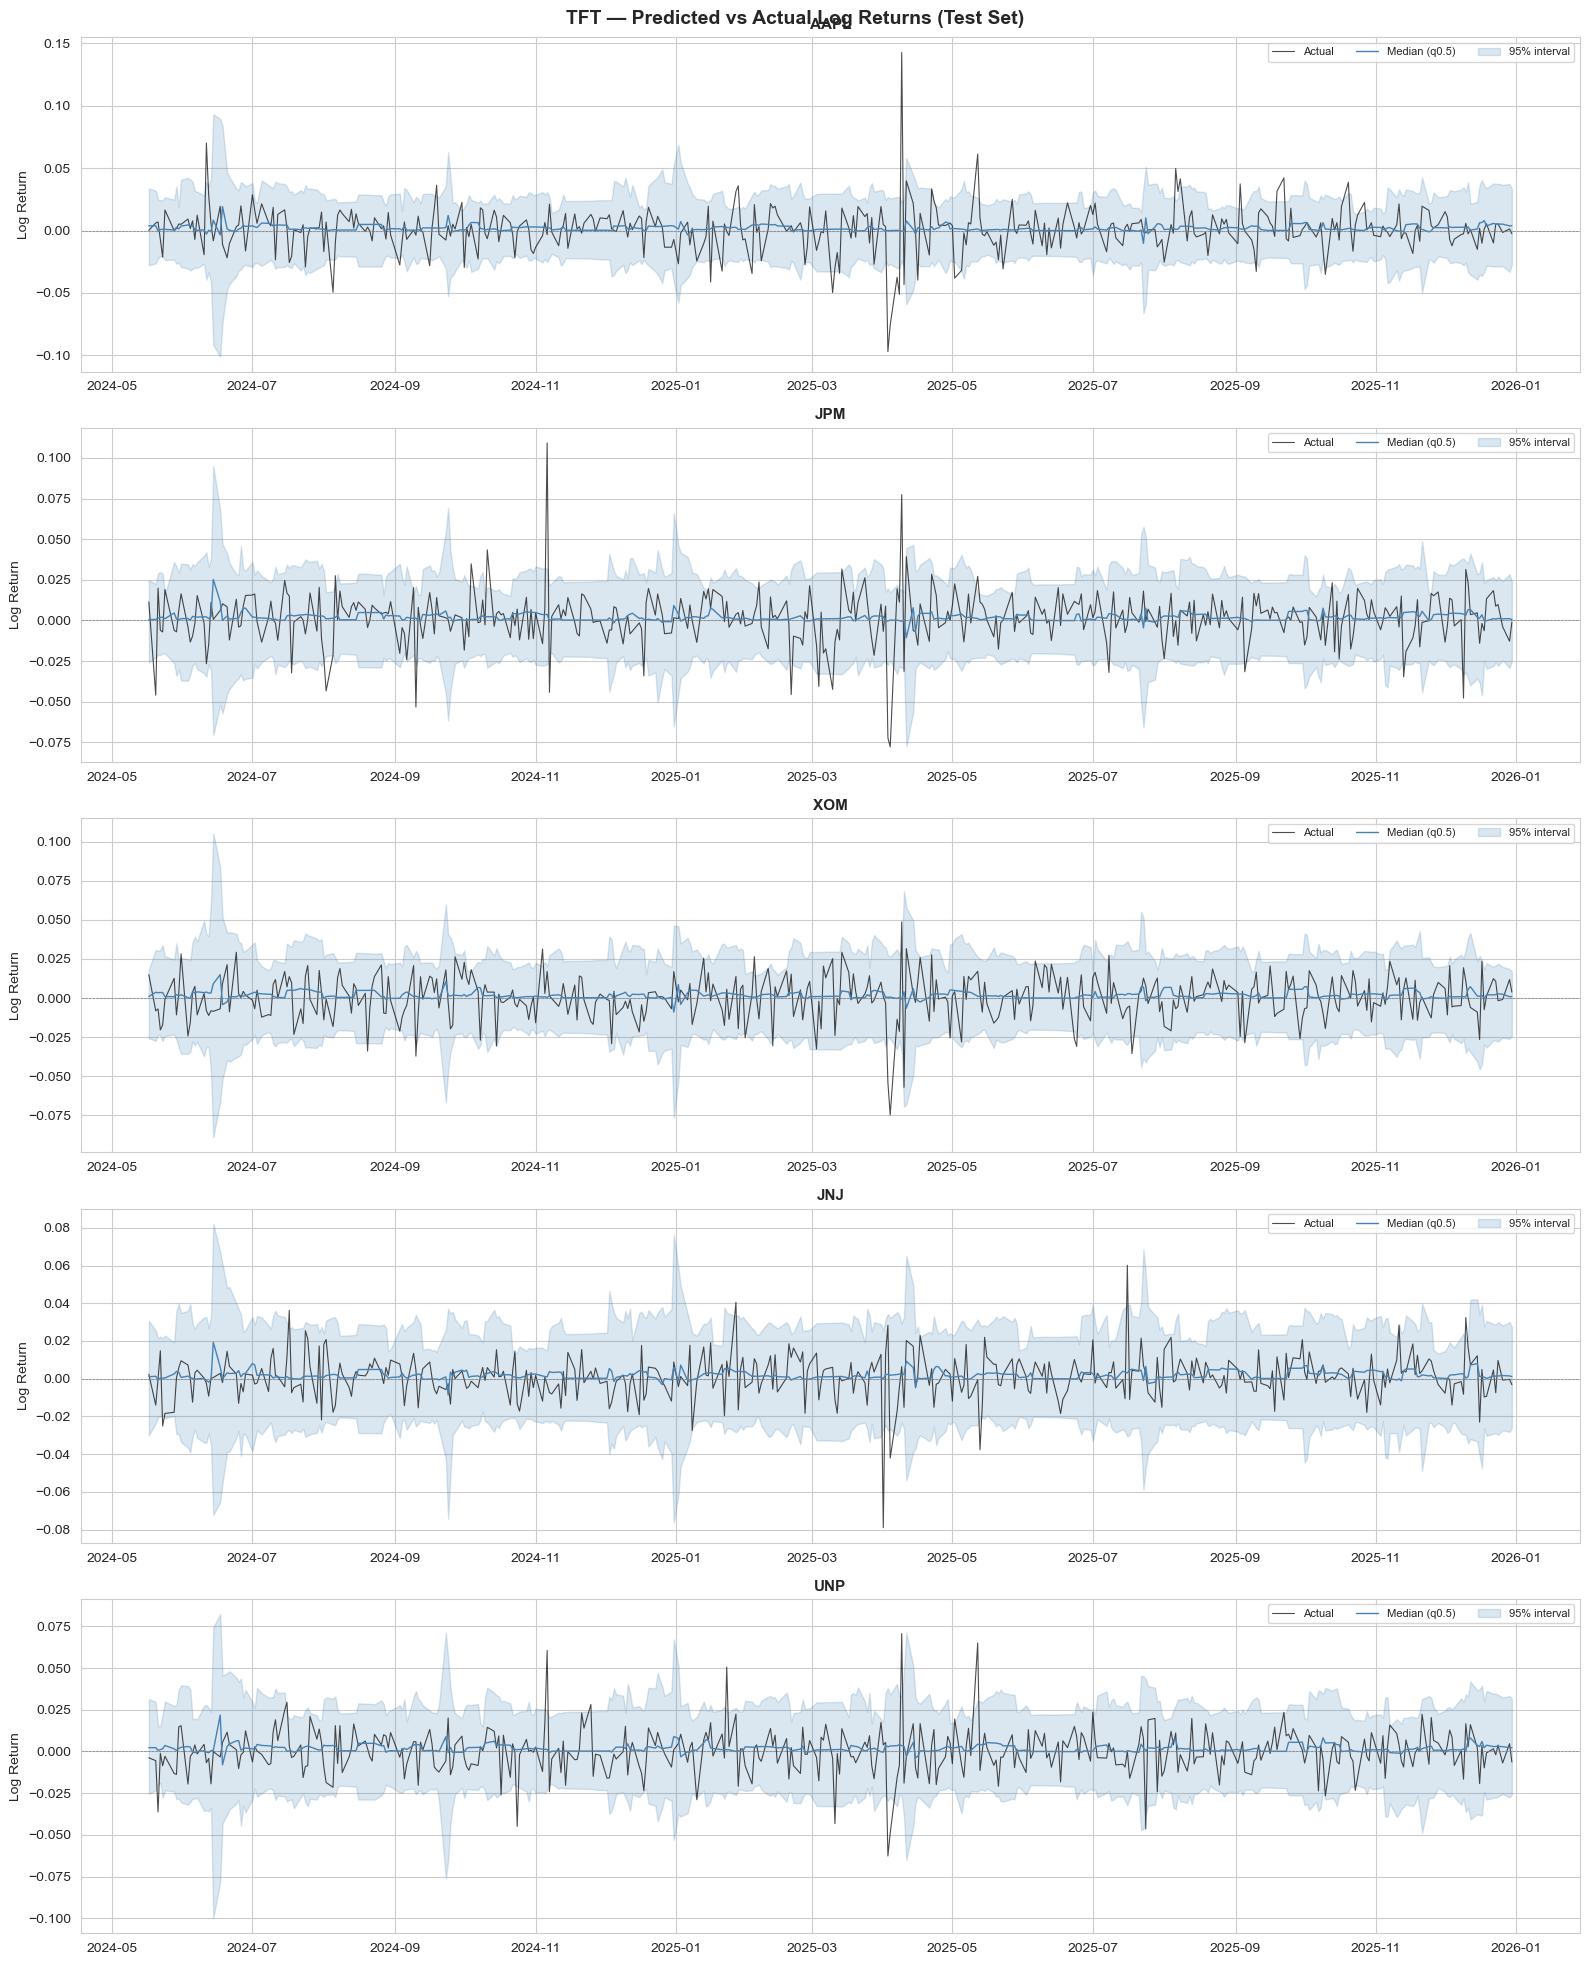

In [85]:
# ── Plot predicted vs actual log returns per stock ─────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    sub = results[results.stock_id == ticker].sort_values("date")
    
    ax.plot(sub["date"], sub["actual"], color="black",    lw=0.8, alpha=0.7, label="Actual")
    ax.plot(sub["date"], sub["q050"],   color="steelblue", lw=1.0, label="Median (q0.5)")
    ax.fill_between(sub["date"], sub["q025"], sub["q975"],
                    color="steelblue", alpha=0.2, label="95% interval")
    ax.axhline(0, color="grey", lw=0.5, linestyle="--")
    ax.set_title(ticker, fontsize=11, fontweight="bold")
    ax.set_ylabel("Log Return")
    ax.legend(fontsize=8, ncol=3)

fig.suptitle("TFT — Predicted vs Actual Log Returns (Test Set)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [86]:
# ── Reload raw prices for test period ─────────────────────────────────────────
top50_raw = pd.read_csv("top50_adjclose_2010_2025.csv", parse_dates=["Date"])
unp_raw   = pd.read_csv("unp_us_d.csv",                 parse_dates=["Date"])

# extract test date range
test_start = results["date"].min()
test_end   = results["date"].max()

# build price dataframe for our 5 stocks
prices = top50_raw[["Date", "AAPL", "JPM", "XOM", "JNJ"]].copy()
prices = prices.rename(columns={"Date": "date"})

unp_prices = unp_raw[["Date", "Close"]].rename(columns={"Date": "date", "Close": "UNP"})
prices = prices.merge(unp_prices, on="date", how="inner")

# filter to test period — include one day before for the P_t anchor
prices = prices[prices["date"] >= test_start].reset_index(drop=True)

print(f"Price rows : {len(prices)}")
print(prices.head())

Price rows : 406
        date        AAPL         JPM         XOM         JNJ     UNP
0 2024-05-17  188.589127  197.334701  113.549759  146.546677  244.97
1 2024-05-20  189.751236  188.459992  112.629143  144.511841  243.63
2 2024-05-21  191.052399  192.256576  111.850883  144.483185  234.96
3 2024-05-22  189.612167  191.090607  109.601524  146.642212  234.71
4 2024-05-23  185.619308  189.751190  107.731812  143.011978  232.71


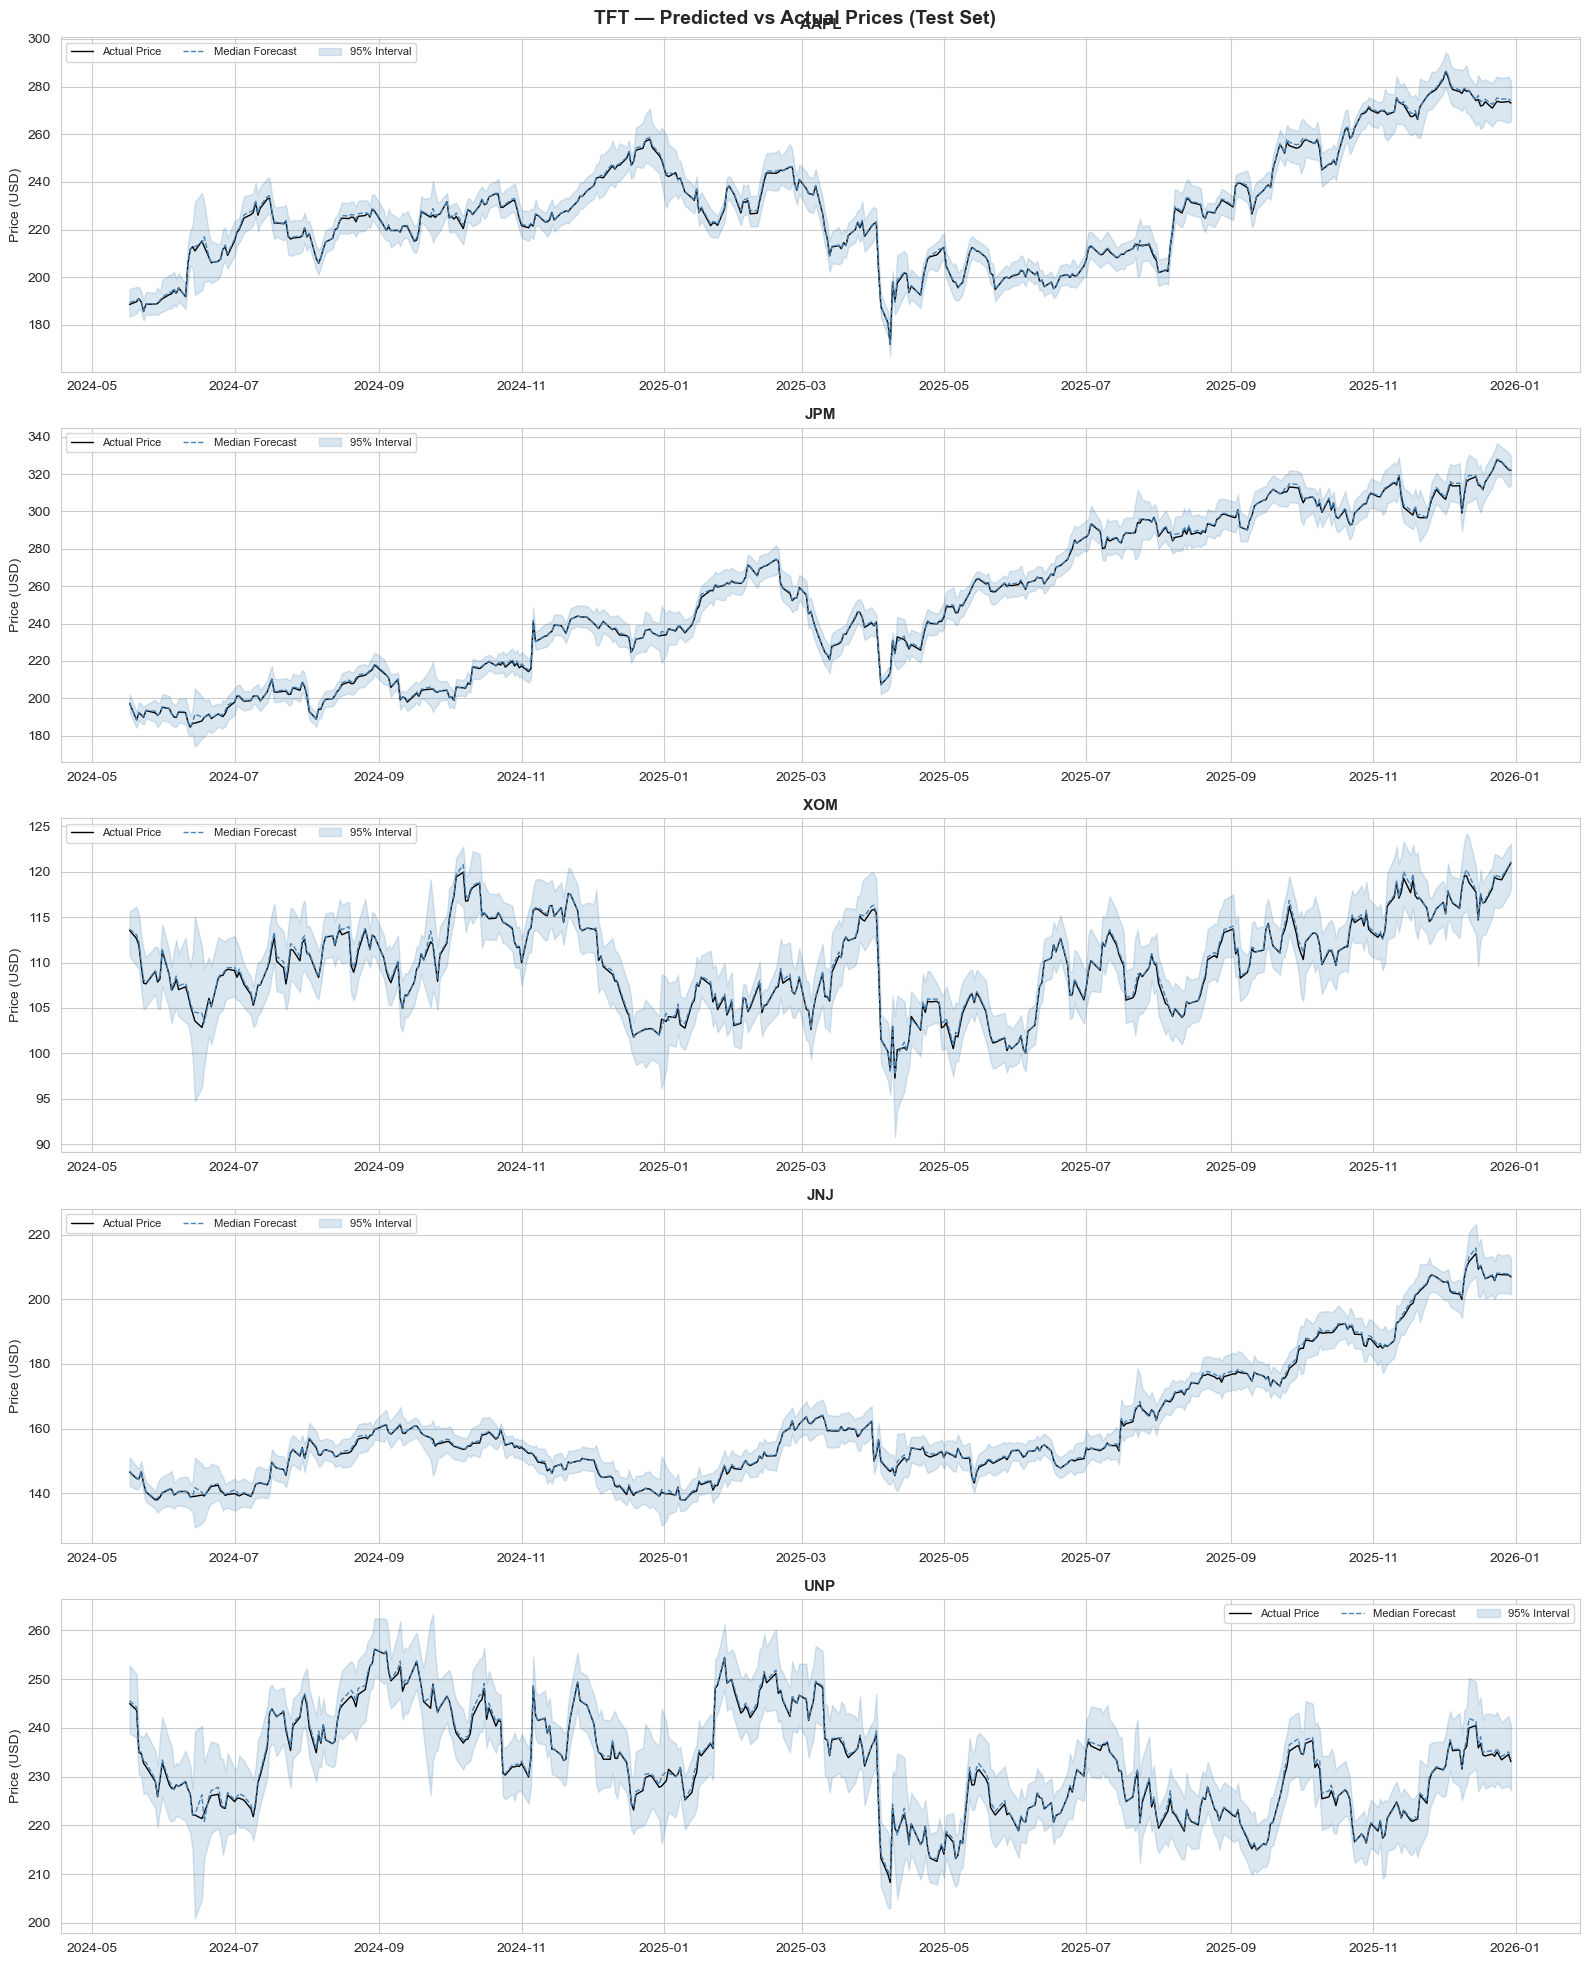

In [88]:
# ── Convert log return predictions to prices ───────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    actual_prices = prices[["date", ticker]].sort_values("date").reset_index(drop=True)
    sub = results[results.stock_id == ticker].sort_values("date").reset_index(drop=True)

    # align on date — P_t is the price on the same date as the prediction
    # prediction for t+1 uses P_t as anchor
    merged = sub.merge(actual_prices, on="date", how="inner")

    P_t         = merged[ticker].values
    pred_median = P_t * np.exp(merged["q050"].values)
    pred_lower  = P_t * np.exp(merged["q025"].values)
    pred_upper  = P_t * np.exp(merged["q975"].values)

    ax.plot(actual_prices["date"], actual_prices[ticker],
            color="black", lw=1.0, label="Actual Price")
    ax.plot(merged["date"], pred_median,
            color="steelblue", lw=1.0, linestyle="--", label="Median Forecast")
    ax.fill_between(merged["date"], pred_lower, pred_upper,
                    color="steelblue", alpha=0.2, label="95% Interval")

    ax.set_title(ticker, fontsize=11, fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=8, ncol=3)

fig.suptitle("TFT — Predicted vs Actual Prices (Test Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Evaluation metrics ─────────────────────────────────────────────────────────

def pinball_loss(actual, predicted, quantile):
    err = actual - predicted
    return np.mean(np.where(err >= 0, quantile * err, (quantile - 1) * err))

metrics = []

for ticker in TICKERS:
    sub = results[results.stock_id == ticker].copy()

    actual = sub["actual"].values
    q025   = sub["q025"].values
    q050   = sub["q050"].values
    q975   = sub["q975"].values

    # pinball losses
    pb025 = pinball_loss(actual, q025, 0.025)
    pb050 = pinball_loss(actual, q050, 0.500)
    pb975 = pinball_loss(actual, q975, 0.975)

    # coverage — what fraction of actuals fall inside the 95% interval
    coverage = np.mean((actual >= q025) & (actual <= q975))

    # interval width
    width = np.mean(q975 - q025)

    metrics.append({
        "stock"       : ticker,
        "pinball_025" : round(pb025, 6),
        "pinball_050" : round(pb050, 6),
        "pinball_975" : round(pb975, 6),
        "coverage_95" : round(coverage, 4),
        "avg_width"   : round(width, 6),
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

stock  pinball_025  pinball_050  pinball_975  coverage_95  avg_width
 AAPL     0.001474     0.006014     0.001530       0.8966   0.056491
  JPM     0.001432     0.005554     0.001190       0.9236   0.056350
  XOM     0.001011     0.005479     0.000826       0.9483   0.056236
  JNJ     0.000942     0.004069     0.000829       0.9729   0.056619
  UNP     0.000999     0.004910     0.001091       0.9507   0.056282


In [90]:
# ── Naive benchmark — predict zero return every day ────────────────────────────
naive_metrics = []

for ticker in TICKERS:
    sub    = results[results.stock_id == ticker].copy()
    actual = sub["actual"].values

    # naive point forecast: zero return
    naive_pred = np.zeros(len(actual))

    # naive interval: use historical std from training set
    train_std = (panel[(panel.stock_id == ticker) & (panel.split == "train")]
                 ["log_return"].std())

    naive_q025 = -1.96 * train_std
    naive_q975 =  1.96 * train_std

    pb050     = pinball_loss(actual, naive_pred,                    0.500)
    pb025     = pinball_loss(actual, np.full(len(actual), naive_q025), 0.025)
    pb975     = pinball_loss(actual, np.full(len(actual), naive_q975), 0.975)
    coverage  = np.mean((actual >= naive_q025) & (actual <= naive_q975))
    width     = naive_q975 - naive_q025

    naive_metrics.append({
        "stock"       : ticker,
        "pinball_025" : round(pb025, 6),
        "pinball_050" : round(pb050, 6),
        "pinball_975" : round(pb975, 6),
        "coverage_95" : round(coverage, 4),
        "avg_width"   : round(width, 6),
    })

naive_df = pd.DataFrame(naive_metrics)

print("=== TFT ===")
print(metrics_df.to_string(index=False))
print("\n=== Naive (zero return + historical ±1.96σ) ===")
print(naive_df.to_string(index=False))

=== TFT ===
stock  pinball_025  pinball_050  pinball_975  coverage_95  avg_width
 AAPL     0.001474     0.006014     0.001530       0.8966   0.056491
  JPM     0.001432     0.005554     0.001190       0.9236   0.056350
  XOM     0.001011     0.005479     0.000826       0.9483   0.056236
  JNJ     0.000942     0.004069     0.000829       0.9729   0.056619
  UNP     0.000999     0.004910     0.001091       0.9507   0.056282

=== Naive (zero return + historical ±1.96σ) ===
stock  pinball_025  pinball_050  pinball_975  coverage_95  avg_width
 AAPL     0.001324     0.005903     0.001370       0.9532   0.073280
  JPM     0.001308     0.005472     0.001169       0.9655   0.070774
  XOM     0.001102     0.005310     0.000931       0.9877   0.072381
  JNJ     0.000835     0.004042     0.000777       0.9704   0.046212
  UNP     0.001029     0.004811     0.001110       0.9754   0.065740


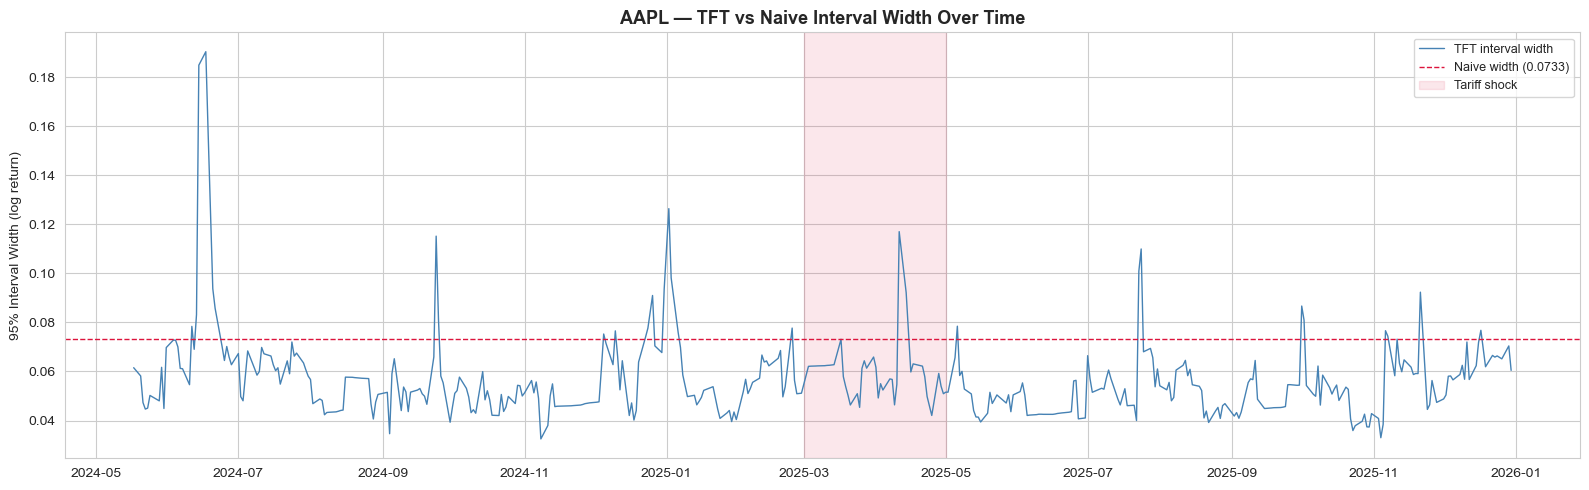

In [91]:
# ── Interval width over time — TFT vs Naive ────────────────────────────────────
ticker = "AAPL"  # most interesting given its volatility

sub = results[results.stock_id == ticker].sort_values("date").reset_index(drop=True)
tft_width   = sub["q975"] - sub["q025"]

train_std   = (panel[(panel.stock_id == ticker) & (panel.split == "train")]
               ["log_return"].std())
naive_width = 2 * 1.96 * train_std  # constant

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(sub["date"], tft_width, color="steelblue", lw=1.0, label="TFT interval width")
ax.axhline(naive_width, color="crimson", lw=1.0, linestyle="--", label=f"Naive width ({naive_width:.4f})")

# shade the March 2025 shock region
ax.axvspan(pd.Timestamp("2025-03-01"), pd.Timestamp("2025-05-01"),
           alpha=0.1, color="crimson", label="Tariff shock")

ax.set_ylabel("95% Interval Width (log return)")
ax.set_title(f"{ticker} — TFT vs Naive Interval Width Over Time", 
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

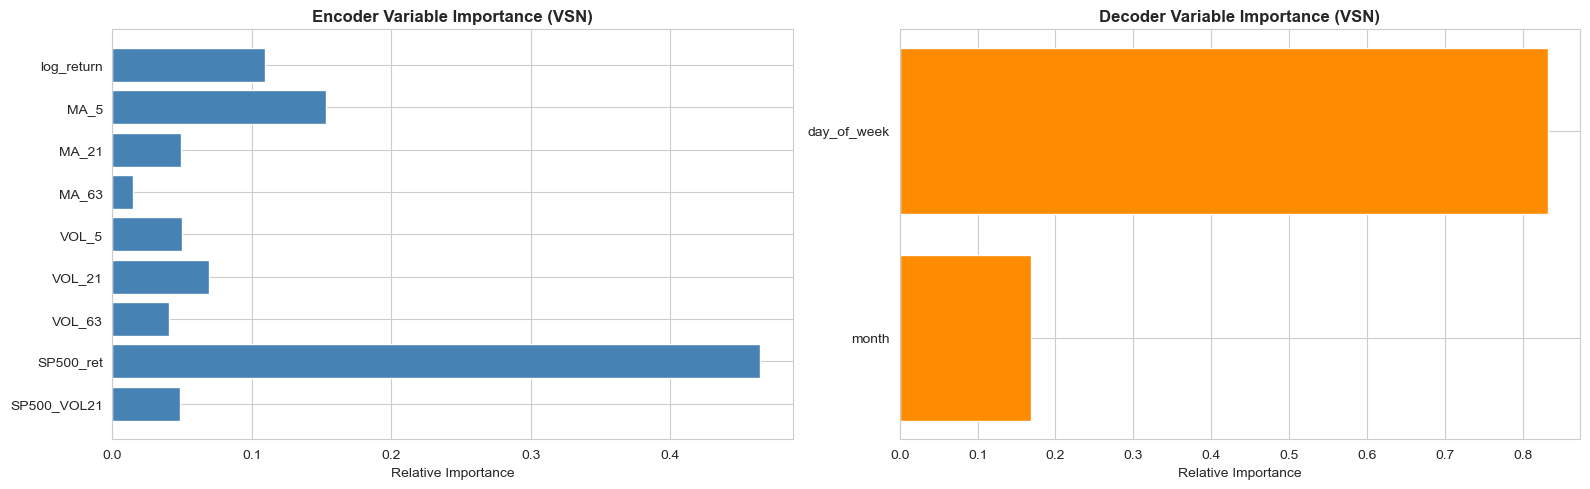

In [95]:
# ── Variable importance — plot ─────────────────────────────────────────────────
encoder_vars = ["log_return", "MA_5", "MA_21", "MA_63",
                "VOL_5", "VOL_21", "VOL_63", "SP500_ret", "SP500_VOL21"]
decoder_vars = ["day_of_week", "month"]

# average across timesteps, take first 9 columns
enc_imp = encoder_importance.numpy()[:-1, :9].mean(axis=0)  # drop last NaN row
dec_imp = decoder_importance.numpy()

enc_imp = enc_imp / enc_imp.sum()  # normalize to sum to 1
dec_imp = dec_imp / dec_imp.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# encoder
axes[0].barh(encoder_vars, enc_imp, color="steelblue")
axes[0].set_xlabel("Relative Importance")
axes[0].set_title("Encoder Variable Importance (VSN)", fontweight="bold")
axes[0].invert_yaxis()

# decoder
axes[1].barh(decoder_vars, dec_imp, color="darkorange")
axes[1].set_xlabel("Relative Importance")
axes[1].set_title("Decoder Variable Importance (VSN)", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Project Report: Multi-Entity Stock Return Forecasting with Temporal Fusion Transformer

**Author:** Felipe  
**Date:** March 2026  
**Framework:** PyTorch Forecasting + PyTorch Lightning  

---

## 1. Overview

This project applies the Temporal Fusion Transformer (TFT) to the problem of
multi-entity daily stock return forecasting. A single model is trained jointly
on five stocks drawn from distinct market sectors, leveraging both
entity-specific and shared market-wide signals. The primary objective is to
produce calibrated one-step-ahead probabilistic forecasts in the form of
quantile predictions at τ ∈ {0.025, 0.50, 0.975}, yielding a 95% prediction
interval and a median point estimate.

---

## 2. Data

**Sources:**
- `top50_adjclose_2010_2025.csv` — adjusted closing prices for the S&P 500
  top 50 constituents, sourced from Yahoo Finance
- `unp_us_d.csv` — Union Pacific daily OHLCV data
- `spx_d.csv` — S&P 500 index daily OHLCV data

**Universe:**

| Ticker | Company            | Sector       |
|--------|--------------------|--------------|
| AAPL   | Apple Inc.         | Technology   |
| JPM    | JPMorgan Chase     | Financials   |
| XOM    | ExxonMobil         | Energy       |
| JNJ    | Johnson & Johnson  | Healthcare   |
| UNP    | Union Pacific      | Industrials  |

**Date range:** 2015-04-06 → 2025-12-30  
**Trading days:** 2,702  
**Panel rows:** 13,510 (2,702 days × 5 stocks)  

---

## 3. Feature Engineering

All raw prices were dropped. The model operates entirely on log returns:

$$r_t^{(s)} = \log\left(\frac{P_t^{(s)}}{P_{t-1}^{(s)}}\right)$$

**Entity-specific features (per stock):**
- `log_return` — daily log return (target and lagged input)
- `MA_5`, `MA_21`, `MA_63` — rolling means (1W, 1M, 1Q)
- `VOL_5`, `VOL_21`, `VOL_63` — rolling standard deviations

**Shared market-wide features:**
- `SP500_ret` — S&P 500 log return
- `SP500_VOL21` — S&P 500 21-day rolling volatility

**Known future features:**
- `day_of_week` — calendar effect (0=Monday, 4=Friday)
- `month` — calendar month (1–12)

**Static covariates:**
- `sector` — categorical sector membership per entity

The first 63 rows were dropped to eliminate NaN warmup from the 63-day
rolling window. Entity isolation was verified with unit tests confirming
that rolling statistics were computed independently per stock.

---

## 4. Dataset Structure

The panel is stored in long format — one row per (stock, date) pair —
as required by PyTorch Forecasting's `TimeSeriesDataSet` API.

**Chronological split (no lookahead bias):**

| Split      | Proportion | Trading Days | Date Range                    |
|------------|------------|--------------|-------------------------------|
| Train      | 70%        | ~1,891       | 2015-04-06 → 2022-10-xx       |
| Validation | 15%        | ~405         | 2022-10-xx → 2024-05-xx       |
| Test       | 15%        | ~406         | 2024-05-17 → 2025-12-30       |

---

## 5. Model Architecture

**Framework:** `pytorch_forecasting.TemporalFusionTransformer`

**Hyperparameters:**

| Parameter              | Value                      |
|------------------------|----------------------------|
| `hidden_size`          | 32                         |
| `lstm_layers`          | 1                          |
| `attention_head_size`  | 4                          |
| `dropout`              | 0.2                        |
| `hidden_continuous_size` | 16                       |
| `min_encoder_length`   | 63 (1 quarter)             |
| `max_encoder_length`   | 126 (2 quarters)           |
| `min_prediction_length`| 1                          |
| `max_prediction_length`| 1 (one-step-ahead only)    |
| `loss`                 | QuantileLoss [0.025, 0.5, 0.975] |
| `target_normalizer`    | None (log returns are near-stationary) |
| `batch_size`           | 128                        |
| `learning_rate`        | 1e-3                       |
| `max_epochs`           | 100 (early stopping)       |
| `patience`             | 10                         |
| **Total parameters**   | **74,431**                 |

**Architecture components (in order):**
1. `MultiEmbedding` — projects categoricals to R^32
2. `prescalers` — scales continuous inputs
3. `static_variable_selection` (VSN) — gates static features
4. `encoder_variable_selection` (VSN) — gates observed time-varying features
5. `decoder_variable_selection` (VSN) — gates known future features
6. 4× `GatedResidualNetwork` — static context vectors for LSTM init,
   cell state, enrichment, and variable selection modulation
7. `lstm_encoder` / `lstm_decoder` — temporal processing (8.4K params each)
8. `post_lstm_gate_encoder` + `AddNorm` — gated skip connection
9. `static_enrichment` GRN — enriches temporal features with static context
10. `InterpretableMultiHeadAttention` — 4-head temporal self-attention
11. `pos_wise_ff` GRN — position-wise feedforward
12. `output_layer` — linear projection to 3 quantiles

---

## 6. Training

Training was performed on CPU (32GB RAM). Early stopping triggered at
**epoch 30**, well before the 100-epoch ceiling.

**Best validation loss:** 0.004019 (pinball loss, summed across 3 quantiles)

The loss curve showed consistent improvement from epoch 1 through ~epoch 20,
after which the model plateaued — consistent with having reached its capacity
ceiling given the signal available in the features.

---

## 7. Evaluation Results

### 7.1 Quantitative Metrics (Test Set)

**TFT:**

| Stock | Pinball 0.025 | Pinball 0.50 | Pinball 0.975 | Coverage 95% | Avg Width |
|-------|--------------|--------------|----------------|--------------|-----------|
| AAPL  | 0.001474     | 0.006014     | 0.001530       | 89.66%       | 0.056491  |
| JPM   | 0.001432     | 0.005554     | 0.001190       | 92.36%       | 0.056350  |
| XOM   | 0.001011     | 0.005479     | 0.000826       | 94.83%       | 0.056236  |
| JNJ   | 0.000942     | 0.004069     | 0.000829       | 97.29%       | 0.056619  |
| UNP   | 0.000999     | 0.004910     | 0.001091       | 95.07%       | 0.056282  |

**Naive benchmark (zero return + historical ±1.96σ interval):**

| Stock | Pinball 0.025 | Pinball 0.50 | Pinball 0.975 | Coverage 95% | Avg Width |
|-------|--------------|--------------|----------------|--------------|-----------|
| AAPL  | 0.001324     | 0.005903     | 0.001370       | 95.32%       | 0.073280  |
| JPM   | 0.001308     | 0.005472     | 0.001169       | 96.55%       | 0.070774  |
| XOM   | 0.001102     | 0.005310     | 0.000931       | 98.77%       | 0.072381  |
| JNJ   | 0.000835     | 0.004042     | 0.000777       | 97.04%       | 0.046212  |
| UNP   | 0.001029     | 0.004811     | 0.001110       | 97.54%       | 0.065740  |

### 7.2 Interpretation

**Point forecast (τ = 0.50):** TFT and naive are statistically
indistinguishable. Neither model has directional skill on daily log returns.
This is consistent with the Efficient Market Hypothesis — technical features
alone cannot reliably predict return direction.

**Coverage:** The naive fixed-interval achieves better aggregate coverage
than TFT on all five stocks. TFT's intervals are overconfident on average,
particularly for AAPL (89.66%), driven by the March 2025 tariff shock which
exceeded the model's uncertainty bounds.

**The genuine advantage of TFT:** The interval width is not static — it
varies dynamically over time, widening during high-volatility regimes and
compressing during calm periods. The naive model cannot do this. In the
interval width plot for AAPL, TFT width ranged from ~0.04 to ~0.19 while
the naive held fix